In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

movies = pd.read_csv("Downloads/movies_ratings.csv")

In [3]:
print("\n--- Initial Info ---\n")
print(movies.info())


--- Initial Info ---

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   title   15 non-null     object 
 1   genre   15 non-null     object 
 2   rating  15 non-null     float64
dtypes: float64(1), object(2)
memory usage: 488.0+ bytes
None


In [4]:
movies.drop_duplicates(inplace=True)

# Handle missing values (drop or fill)
movies['rating'] = movies['rating'].fillna(movies['rating'].mean())

# ---------------- Summary Statistics ----------------
mean_rating = movies['rating'].mean()
median_rating = movies['rating'].median()
mode_rating = movies['rating'].mode()[0]

print("\n--- Rating Summary ---\n")
print(f"Mean Rating   : {mean_rating:.2f}")
print(f"Median Rating : {median_rating:.2f}")
print(f"Mode Rating   : {mode_rating:.2f}")


--- Rating Summary ---

Mean Rating   : 8.71
Median Rating : 8.80
Mode Rating   : 8.80


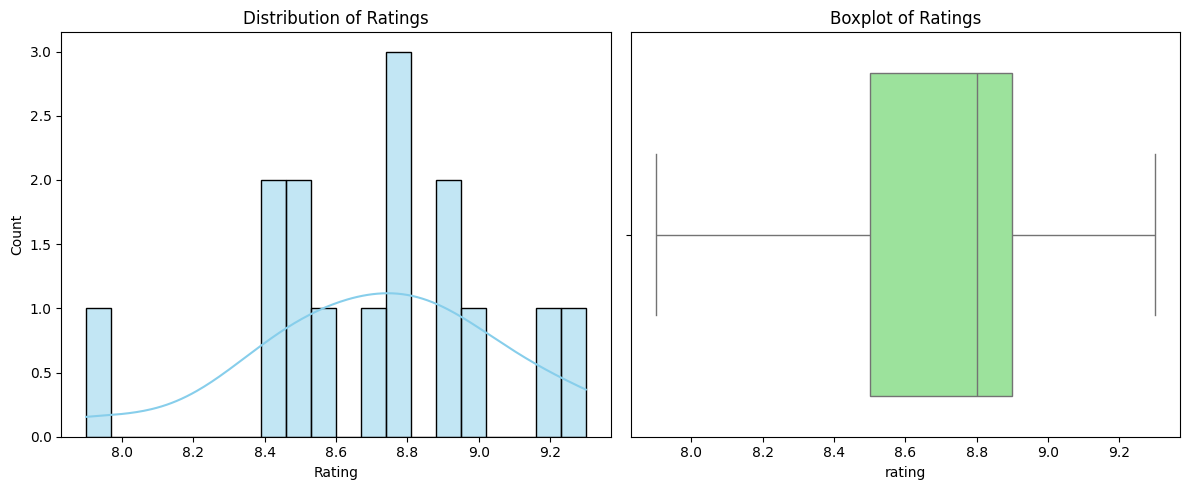

In [5]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(movies['rating'], bins=20, kde=True, color="skyblue")
plt.title("Distribution of Ratings")
plt.xlabel("Rating")

plt.subplot(1, 2, 2)
sns.boxplot(x=movies['rating'], color="lightgreen")
plt.title("Boxplot of Ratings")

plt.tight_layout()
plt.show()

In [6]:
top_movies = movies.sort_values(by="rating", ascending=False).head(10)
print("\n--- Top Rated Movies ---\n")
print(top_movies[['title', 'rating']])


--- Top Rated Movies ---

                                       title  rating
8                   The Shawshank Redemption     9.3
3                              The Godfather     9.2
1                            The Dark Knight     9.0
4                               Pulp Fiction     8.9
9  The Lord of the Rings: Return of the King     8.9
0                                  Inception     8.8
5                               Forrest Gump     8.8
7                                 Fight Club     8.8
6                                 The Matrix     8.7
2                               Interstellar     8.6


/var/folders/z7/fmtdly0n56d_b1hqwv6wbgr40000gn/T/ipykernel_1551/2126542028.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_movies, x="rating", y="title", palette="viridis")


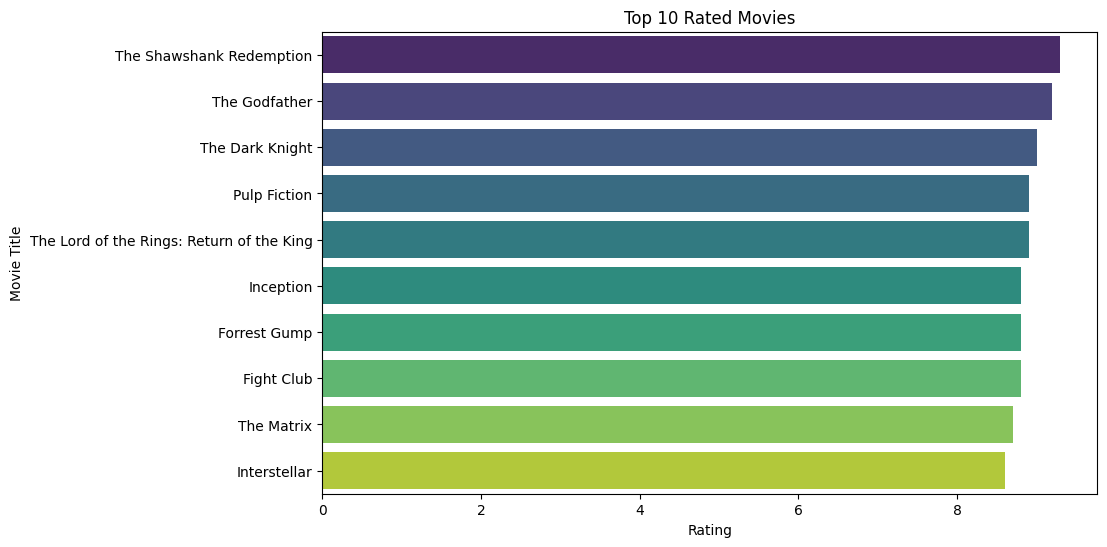

In [7]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top_movies, x="rating", y="title", palette="viridis")
plt.title("Top 10 Rated Movies")
plt.xlabel("Rating")
plt.ylabel("Movie Title")
plt.show()


--- Average Rating by Genre ---

genre
Drama        8.966667
Fantasy      8.900000
Crime        8.833333
Sci-Fi       8.700000
Action       8.633333
Animation    8.500000
Romance      7.900000
Name: rating, dtype: float64


/var/folders/z7/fmtdly0n56d_b1hqwv6wbgr40000gn/T/ipykernel_1551/2120335758.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_ratings.values, y=genre_ratings.index, palette="magma")


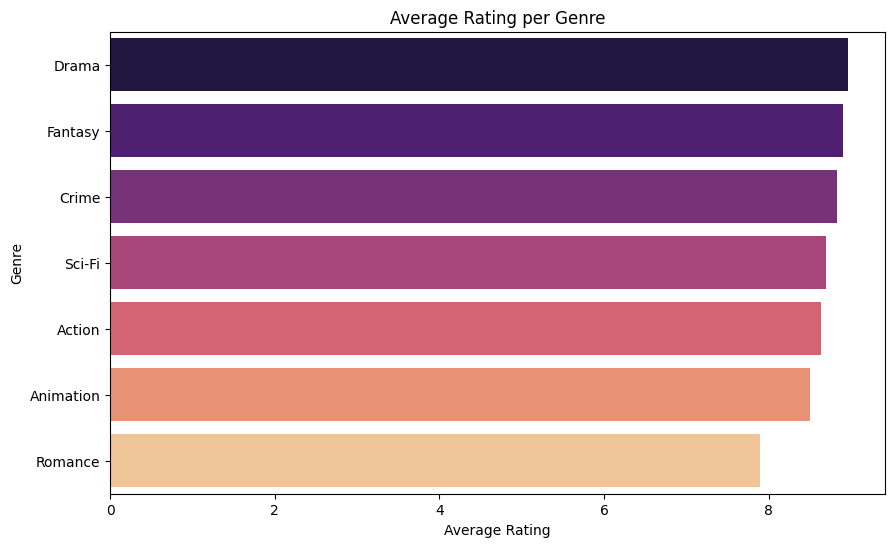

In [8]:
genre_ratings = movies.groupby("genre")['rating'].mean().sort_values(ascending=False)
print("\n--- Average Rating by Genre ---\n")
print(genre_ratings)

plt.figure(figsize=(10, 6))
sns.barplot(x=genre_ratings.values, y=genre_ratings.index, palette="magma")
plt.title("Average Rating per Genre")
plt.xlabel("Average Rating")
plt.ylabel("Genre")
plt.show()

/var/folders/z7/fmtdly0n56d_b1hqwv6wbgr40000gn/T/ipykernel_1551/2975147893.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_ratings.values, y=genre_ratings.index, palette="magma", ax=axes[1, 1])


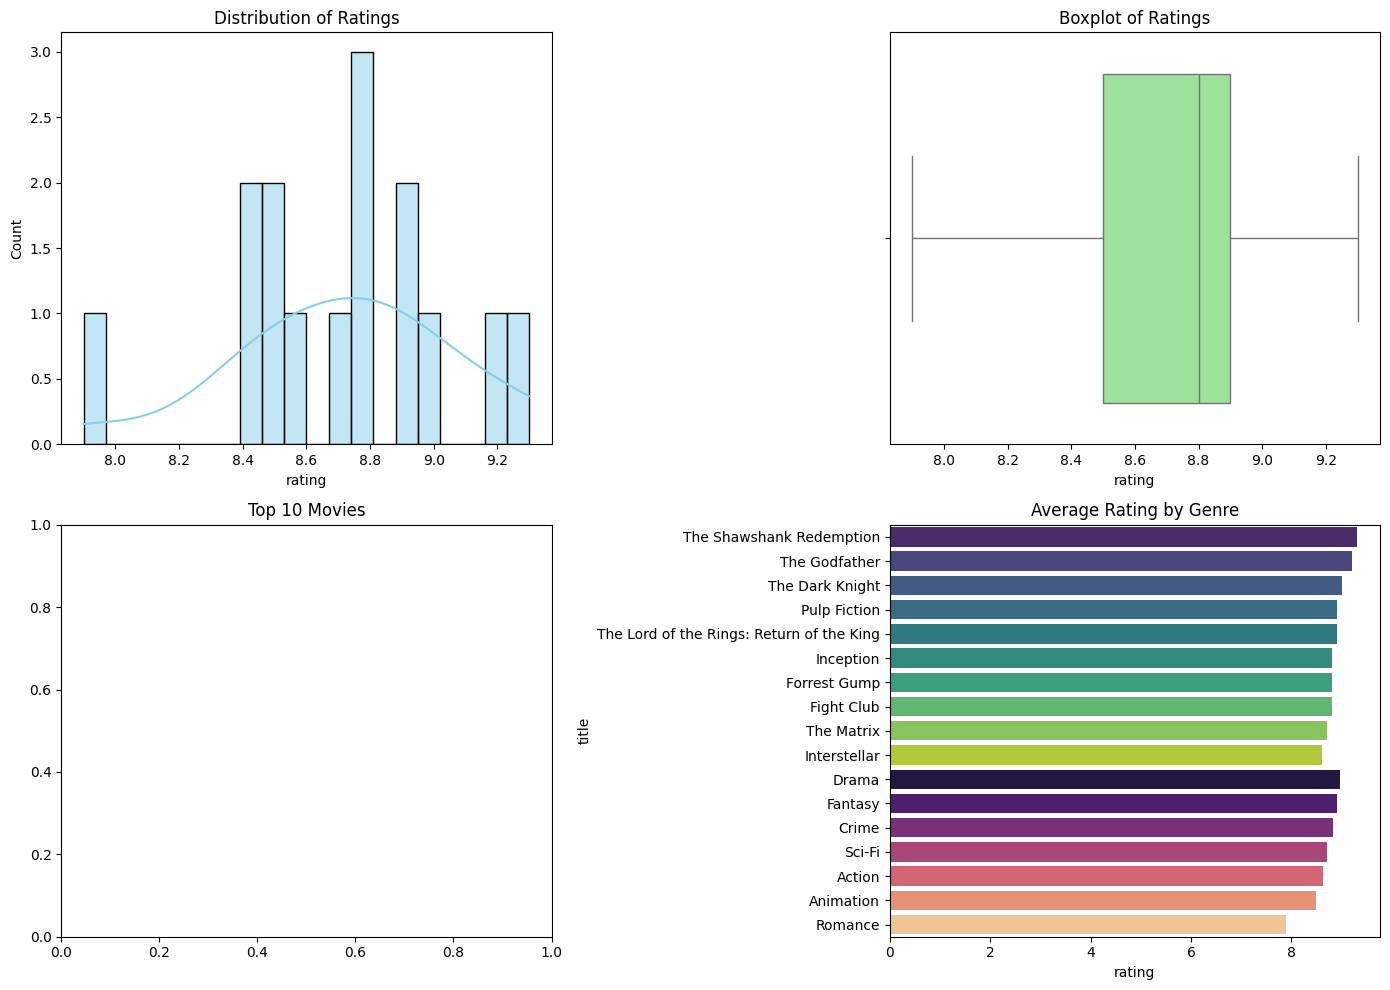

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Ratings Histogram
sns.histplot(movies['rating'], bins=20, kde=True, color="skyblue", ax=axes[0, 0])
axes[0, 0].set_title("Distribution of Ratings")

# Ratings Boxplot
sns.boxplot(x=movies['rating'], color="lightgreen", ax=axes[0, 1])
axes[0, 1].set_title("Boxplot of Ratings")

# Top 10 Movies
sns.barplot(data=top_movies, x="rating", y="title",
            hue="title", palette="viridis", legend=False)

axes[1, 0].set_title("Top 10 Movies")

# Genre Ratings
sns.barplot(x=genre_ratings.values, y=genre_ratings.index, palette="magma", ax=axes[1, 1])
axes[1, 1].set_title("Average Rating by Genre")

plt.tight_layout()
plt.show()
